In [1]:
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
rf = Roboflow(api_key="qs9y6zBonySytcyxj4xf")
project = rf.workspace("test-w9qag").project("braile-block-copy-lml6r")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


# 1. 사전 학습된 모델 로드 (전이 학습 시작점)

In [8]:
model1 = YOLO("yolo11n.pt")

# 2. 학습 시작
data: 위에서 작성한 yaml 파일 경로\
epochs: 학습 반복 횟수\
imgsz: 이미지 크기

In [9]:
# 이전에 저장된 가중치 파일(last.pt)을 불러옵니다.
# 주의: 이전 학습이 중단되어 last.pt가 생성된 경우에만 작동합니다.
# model1 = YOLO("runs/detect/train/weights/last.pt")

results = model1.train(
    data="coco.yaml",
    epochs=1,
    imgsz=640,
    batch=128,
    device=0,
    )

New https://pypi.org/project/ultralytics/8.4.15 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=Fals

Exception in thread Thread-46 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

: 0% ──────────── 0/925  4.0s


KeyboardInterrupt: 

# 3. 이미지 추론


image 1/1 /content/outside01.jpg: 640x480 (no detections), 10.6ms
Speed: 3.1ms preprocess, 10.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
추론이 완료되었습니다. 'outside_predict1.jpg' 파일을 확인해 보세요.


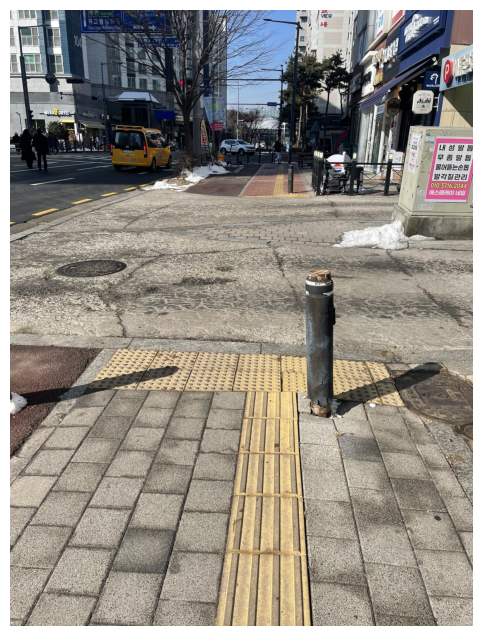

In [ ]:
# 1. 학습된 최적 모델 로드
model_pred = YOLO("/content/runs/obb/train/weights/best.pt")

# 2. 이미지 추론 수행
results = model_pred.predict(source="outside01.jpg")

# 3. 추론 결과 시각화 및 파일 저장
# plot() 메서드는 박스가 그려진 이미지(Numpy 배열)를 반환합니다.
res_plotted = results[0].plot()
cv2.imwrite("outside_predict1.jpg", res_plotted)

print("추론이 완료되었습니다. 'outside_predict1.jpg' 파일을 확인해 보세요.")

# 이미지 열기
img = Image.open("outside_predict1.jpg")

# 이미지 출력
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()